In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [3]:
DATA_PATH = "Loan_data.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Wymiary danych (raw):", df.shape)
print("Przykładowe kolumny:", list(df.columns[:15]))


Wymiary danych (raw): (42536, 151)
Przykładowe kolumny: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status']


In [4]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
df["target_default"] = (df["loan_status"] == "Charged Off").astype(int)

print("\nWymiary po filtrze klas:", df.shape)
print("Default rate:", round(df["target_default"].mean(), 4))
print(df["loan_status"].value_counts())



Wymiary po filtrze klas: (39786, 152)
Default rate: 0.1425
loan_status
Fully Paid     34116
Charged Off     5670
Name: count, dtype: int64


In [5]:
def parse_emp_length(x):
    """'10+ years' -> 10, '< 1 year' -> 0.5, '3 years' -> 3"""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["n/a", "na", "none", "nan"]:
        return np.nan
    if "<" in s:
        return 0.5
    if "10+" in s:
        return 10.0
    m = re.search(r"(\d+)", s)
    return float(m.group(1)) if m else np.nan

def pct_to_float(x):
    """'13.56%' -> 0.1356"""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("%", "")
    try:
        return float(s) / 100.0
    except:
        return np.nan

def term_to_int(x):
    """' 36 months' -> 36"""
    if pd.isna(x):
        return np.nan
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else np.nan

In [6]:
for col in ["issue_d", "earliest_cr_line"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# % jako float
if "int_rate" in df.columns:
    df["int_rate_num"] = df["int_rate"].apply(pct_to_float) if df["int_rate"].dtype == object else df["int_rate"]

if "revol_util" in df.columns:
    df["revol_util_num"] = df["revol_util"].apply(pct_to_float) if df["revol_util"].dtype == object else df["revol_util"]

# term jako liczba
if "term" in df.columns:
    df["term_num"] = df["term"].apply(term_to_int)

# emp_length jako liczba
if "emp_length" in df.columns:
    df["emp_length_num"] = df["emp_length"].apply(parse_emp_length)

# Wiek kredytowy (w latach) — przydatne już na etapie przetwarzania
if "issue_d" in df.columns and "earliest_cr_line" in df.columns:
    df["credit_age_years"] = (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25

# FICO avg — przydatne jako “czysta” cecha numeryczna
if "fico_range_low" in df.columns and "fico_range_high" in df.columns:
    df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2.0

In [7]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
high_missing_cols = missing_ratio[missing_ratio > 0.40].index.tolist()

print("\nLiczba kolumn z >40% braków:", len(high_missing_cols))
print("Przykłady:", high_missing_cols[:15])



Liczba kolumn z >40% braków: 91
Przykłady: ['avg_cur_bal', 'il_util', 'bc_open_to_buy', 'member_id', 'acc_open_past_24mths', 'inq_last_12m', 'total_cu_tl', 'inq_fi', 'total_rev_hi_lim', 'all_util', 'max_bal_bc', 'open_rv_24m', 'open_rv_12m', 'total_bal_il', 'tot_hi_cred_lim']


In [8]:
leak_keywords = [
    "pymnt", "out_prncp", "total_pymnt", "total_rec", "recover", "collection",
    "last_pymnt", "next_pymnt", "settlement", "hardship", "debt_settlement",
    "last_fico", "last_credit_pull", "policy_code", "url", "desc"
]
leak_cols = [c for c in df.columns if any(k in c.lower() for k in leak_keywords)]

print("\nLiczba potencjalnie przeciekowych kolumn:", len(leak_cols))
print("Przykłady:", leak_cols[:20])


Liczba potencjalnie przeciekowych kolumn: 40
Przykłady: ['pymnt_plan', 'url', 'desc', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code']


In [9]:
drop_cols = set([
    "loan_status", "target_default",
    "id", "member_id",
    "emp_title", "title", "desc", "url",
    "issue_d", "earliest_cr_line"
])

drop_cols |= set(high_missing_cols)
drop_cols |= set(leak_cols)


In [10]:
y = df["target_default"].copy()
X = df.drop(columns=list(drop_cols), errors="ignore")

print("\nX shape:", X.shape, "| y shape:", y.shape)


X shape: (39786, 39) | y shape: (39786,)


In [11]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("\nLiczba cech numerycznych:", len(num_cols))
print("Liczba cech kategorycznych:", len(cat_cols))

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)


Liczba cech numerycznych: 25
Liczba cech kategorycznych: 14


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train default rate:", round(y_train.mean(), 4))
print("Test default rate:", round(y_test.mean(), 4))



Train shape: (31828, 39) | Test shape: (7958, 39)
Train default rate: 0.1425
Test default rate: 0.1425


In [13]:
X_train_ready = preprocess.fit_transform(X_train)
X_test_ready = preprocess.transform(X_test)

print("\nPo preprocessingu:")
print("X_train_ready shape:", X_train_ready.shape)
print("X_test_ready shape:", X_test_ready.shape)


Po preprocessingu:
X_train_ready shape: (31828, 2395)
X_test_ready shape: (7958, 2395)


In [14]:
# 2) EDA (100 pkt) — wykresy + testy statystyczne + odpowiedzi

In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re
import warnings
warnings.filterwarnings("ignore")

In [16]:
def parse_emp_length(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    if "<" in s: return 0.5
    if "10+" in s: return 10.0
    m = re.search(r"(\d+)", s)
    return float(m.group(1)) if m else np.nan

def pct_to_float(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().replace("%","")
    try: return float(s)/100.0
    except: return np.nan

def term_to_int(x):
    if pd.isna(x): return np.nan
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else np.nan

In [17]:
if "target_default" not in df.columns:
    df = df[df["loan_status"].isin(["Fully Paid","Charged Off"])].copy()
    df["target_default"] = (df["loan_status"]=="Charged Off").astype(int)

if "fico_avg" not in df.columns and "fico_range_low" in df.columns and "fico_range_high" in df.columns:
    df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2.0

if "issue_d" in df.columns and df["issue_d"].dtype == object:
    df["issue_d"] = pd.to_datetime(df["issue_d"], errors="coerce")
if "earliest_cr_line" in df.columns and df["earliest_cr_line"].dtype == object:
    df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")

if "credit_age_years" not in df.columns and "issue_d" in df.columns and "earliest_cr_line" in df.columns:
    df["credit_age_years"] = (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25

if "emp_length_num" not in df.columns and "emp_length" in df.columns:
    df["emp_length_num"] = df["emp_length"].apply(parse_emp_length)

if "int_rate_num" not in df.columns and "int_rate" in df.columns:
    df["int_rate_num"] = df["int_rate"].apply(pct_to_float) if df["int_rate"].dtype==object else df["int_rate"]

if "term_num" not in df.columns and "term" in df.columns:
    df["term_num"] = df["term"].apply(term_to_int)

if "log_annual_inc" not in df.columns and "annual_inc" in df.columns:
    df["log_annual_inc"] = np.log1p(df["annual_inc"])

print("EDA working df shape:", df.shape)
print("Default rate:", round(df["target_default"].mean(), 4))


EDA working df shape: (39786, 159)
Default rate: 0.1425


In [18]:
def ttest_report(col, label):
    """t-test dla różnicy średnich (non-default vs default)"""
    a = df.loc[df["target_default"]==0, col].dropna()
    b = df.loc[df["target_default"]==1, col].dropna()
    res = stats.ttest_ind(a, b, equal_var=False)
    out = {
        "feature": label,
        "mean_non_default": a.mean(),
        "mean_default": b.mean(),
        "diff_default_minus_non": b.mean() - a.mean(),
        "t_stat": res.statistic,
        "p_value": res.pvalue,
        "n_non_default": len(a),
        "n_default": len(b)
    }
    return out

def chi2_report(cat_col, label):
    """Chi-square test dla zależności kategoryczna vs default"""
    ct = pd.crosstab(df[cat_col], df["target_default"])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    default_rate = (ct[1] / ct.sum(axis=1)).sort_values(ascending=False)
    out = {
        "feature": label,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "table": ct,
        "default_rate": default_rate
    }
    return out

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "n.s."

In [19]:
# 2.1 FICO vs spłata (default)

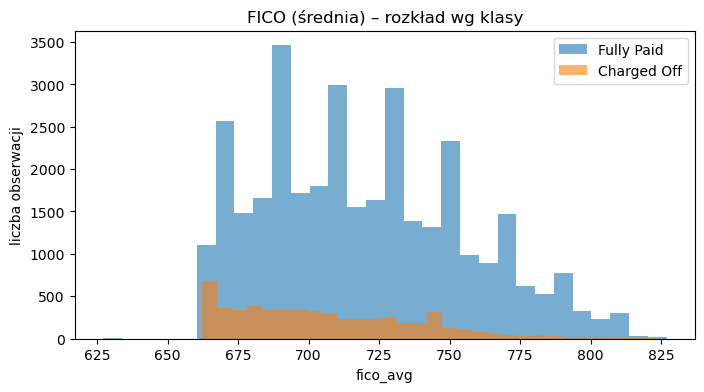

,feature,mean_non_default,mean_default,diff_default_minus_non,t_stat,p_value,n_non_default,n_default
0,FICO (średnia),718.886651,705.634039,-13.252613,28.424215,1.158361e-169,34116,5670


In [20]:
# Wykres: rozkład FICO wg klasy
plt.figure(figsize=(8,4))
plt.hist(df.loc[df["target_default"]==0, "fico_avg"].dropna(), bins=30, alpha=0.6, label="Fully Paid")
plt.hist(df.loc[df["target_default"]==1, "fico_avg"].dropna(), bins=30, alpha=0.6, label="Charged Off")
plt.title("FICO (średnia) – rozkład wg klasy")
plt.xlabel("fico_avg")
plt.ylabel("liczba obserwacji")
plt.legend()
plt.show()

fico_test = ttest_report("fico_avg", "FICO (średnia)")
display(pd.DataFrame([fico_test]))

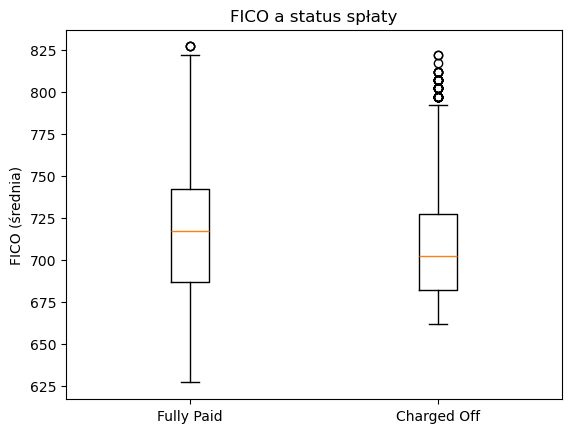

In [47]:
# WYKRES: FICO vs default
plt.figure()
plt.boxplot(
    [df.loc[df.target_default==0,"fico_avg"].dropna(),
     df.loc[df.target_default==1,"fico_avg"].dropna()],
    labels=["Fully Paid","Charged Off"]
)
plt.title("FICO a status spłaty")
plt.ylabel("FICO (średnia)")
plt.show()

In [46]:
# TABELA: średnie FICO + default rate
fico_table = df.groupby("target_default").agg(
    mean_fico=("fico_avg","mean"),
    median_fico=("fico_avg","median"),
    count=("fico_avg","size")
)
fico_table

,mean_fico,median_fico,count
target_default,,,
0,718.886651,717.0,34116
1,705.634039,702.0,5670


In [31]:
# Odpowiedź 1
fico_dir = "wyższy" if fico_test["mean_non_default"] > fico_test["mean_default"] else "niższy"
print("\nODPOWIEDŹ 1:")
print(
    f"Wynik FICO jest silnie powiązany z prawdopodobieństwem spłaty pożyczki. "
    f"Średnia wartość FICO w grupie Fully Paid jest {fico_dir} niż w grupie Charged Off "
    f"(t-test: p={fico_test['p_value']:.3e} {p_to_stars(fico_test['p_value'])}). "
    f"Oznacza to, że wraz ze wzrostem FICO maleje ryzyko niewypłacalności."
)


ODPOWIEDŹ 1:
Wynik FICO jest silnie powiązany z prawdopodobieństwem spłaty pożyczki. Średnia wartość FICO w grupie Fully Paid jest wyższy niż w grupie Charged Off (t-test: p=1.158e-169 ***). Oznacza to, że wraz ze wzrostem FICO maleje ryzyko niewypłacalności.


In [24]:
# 2.2 Wiek kredytowy vs default + relacja z FICO

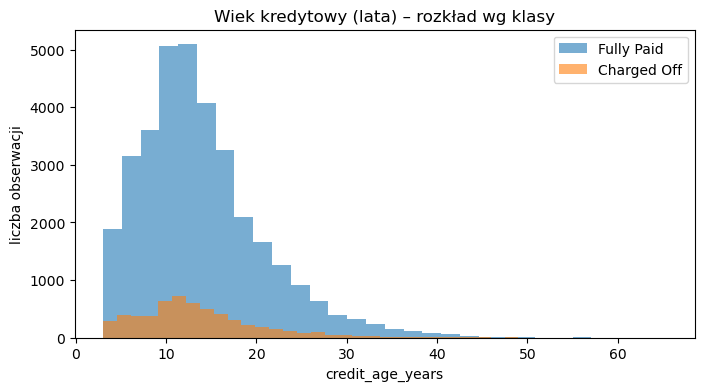

,feature,mean_non_default,mean_default,diff_default_minus_non,t_stat,p_value,n_non_default,n_default
0,Wiek kredytowy (lata),13.845608,13.480291,-0.365317,3.762519,0.000169,34116,5670


In [25]:
plt.figure(figsize=(8,4))
plt.hist(df.loc[df["target_default"]==0, "credit_age_years"].dropna(), bins=30, alpha=0.6, label="Fully Paid")
plt.hist(df.loc[df["target_default"]==1, "credit_age_years"].dropna(), bins=30, alpha=0.6, label="Charged Off")
plt.title("Wiek kredytowy (lata) – rozkład wg klasy")
plt.xlabel("credit_age_years")
plt.ylabel("liczba obserwacji")
plt.legend()
plt.show()

age_test = ttest_report("credit_age_years", "Wiek kredytowy (lata)")
display(pd.DataFrame([age_test]))

In [30]:
# Korelacja FICO vs wiek kredytowy (czy są powiązane)
tmp = df[["fico_avg","credit_age_years"]].dropna()
corr = tmp.corr().iloc[0,1]

print("\nODPOWIEDŹ 2:")
rel = "dodatnio" if corr > 0 else "ujemnie"
print(
    f"Wiek kredytowy jest powiązany z ryzykiem defaultu: w klasie Charged Off "
    f"średni wiek kredytowy jest {'niższy' if age_test['mean_default'] < age_test['mean_non_default'] else 'wyższy'} "
    f"niż w Fully Paid (t-test: p={age_test['p_value']:.3e} {p_to_stars(age_test['p_value'])}). "
    f"Jednocześnie wiek kredytowy jest {rel} skorelowany z FICO (korelacja Pearsona r={corr:.3f}), "
    f"co sugeruje, że część efektu może wynikać z powiązania z jakością kredytową, ale zmienna ta "
    f"wnosi także dodatkową informację (nie jest całkowicie niezależna od FICO)."
)


ODPOWIEDŹ 2:
Wiek kredytowy jest powiązany z ryzykiem defaultu: w klasie Charged Off średni wiek kredytowy jest niższy niż w Fully Paid (t-test: p=1.695e-04 ***). Jednocześnie wiek kredytowy jest dodatnio skorelowany z FICO (korelacja Pearsona r=0.242), co sugeruje, że część efektu może wynikać z powiązania z jakością kredytową, ale zmienna ta wnosi także dodatkową informację (nie jest całkowicie niezależna od FICO).


In [48]:
credit_age_table = df.groupby("target_default").agg(
    mean_credit_age=("credit_age_years","mean"),
    median_credit_age=("credit_age_years","median")
)
credit_age_table

,mean_credit_age,median_credit_age
target_default,,
0,13.845608,12.585900
1,13.480291,12.328542


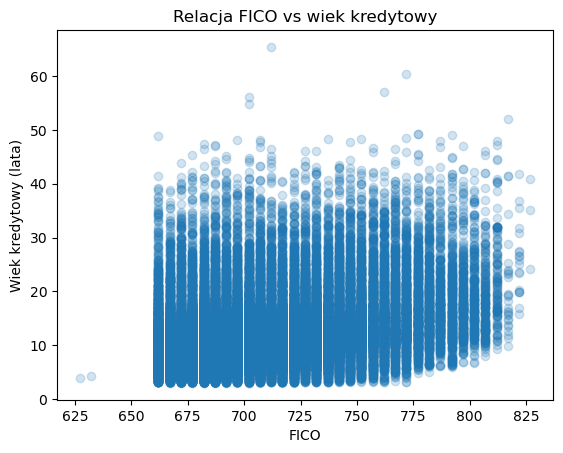

In [49]:
# Diagram rozrzutu: FICO vs wiek kredytowy
plt.figure()
plt.scatter(df["fico_avg"], df["credit_age_years"], alpha=0.2)
plt.xlabel("FICO")
plt.ylabel("Wiek kredytowy (lata)")
plt.title("Relacja FICO vs wiek kredytowy")
plt.show()

In [28]:
# 2.3 Pytanie 3: home_ownership vs default (Chi-square)

Chi-square home_ownership: 26.677730838911266 p= 2.30950625109798e-05


target_default,0,1
home_ownership,,
MORTGAGE,15352,2351
NONE,3,0
OTHER,80,18
OWN,2618,446
RENT,16063,2855


home_ownership
OTHER       0.183673
RENT        0.150914
OWN         0.145561
MORTGAGE    0.132802
NONE        0.000000
Name: default_rate, dtype: float64

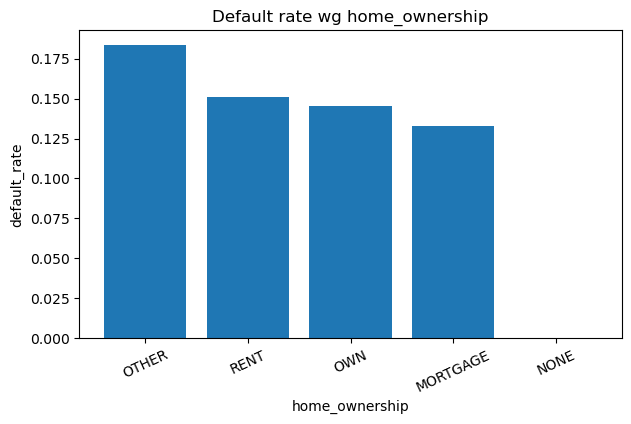


ODPOWIEDŹ 3:
Status posiadania nieruchomości jest istotnie powiązany z ryzykiem defaultu (test Chi-kwadrat: p=2.310e-05 ***). Najwyższy wskaźnik defaultu obserwujemy dla kategorii OTHER, a najniższy dla NONE. Może to odzwierciedlać różnice w stabilności finansowej pomiędzy segmentami.


In [29]:
chi_home = chi2_report("home_ownership", "Home ownership")
print("Chi-square home_ownership:", chi_home["chi2"], "p=", chi_home["p_value"])
display(chi_home["table"])
display(chi_home["default_rate"].rename("default_rate"))

plt.figure(figsize=(7,4))
plt.bar(chi_home["default_rate"].index.astype(str), chi_home["default_rate"].values)
plt.title("Default rate wg home_ownership")
plt.xlabel("home_ownership")
plt.ylabel("default_rate")
plt.xticks(rotation=25)
plt.show()

print("\nODPOWIEDŹ 3:")
top = chi_home["default_rate"].index[0]
bottom = chi_home["default_rate"].index[-1]
print(
    f"Status posiadania nieruchomości jest istotnie powiązany z ryzykiem defaultu "
    f"(test Chi-kwadrat: p={chi_home['p_value']:.3e} {p_to_stars(chi_home['p_value'])}). "
    f"Najwyższy wskaźnik defaultu obserwujemy dla kategorii {top}, a najniższy dla {bottom}. "
    f"Może to odzwierciedlać różnice w stabilności finansowej pomiędzy segmentami."
)


In [32]:
# 2.4 Dochód roczny vs default

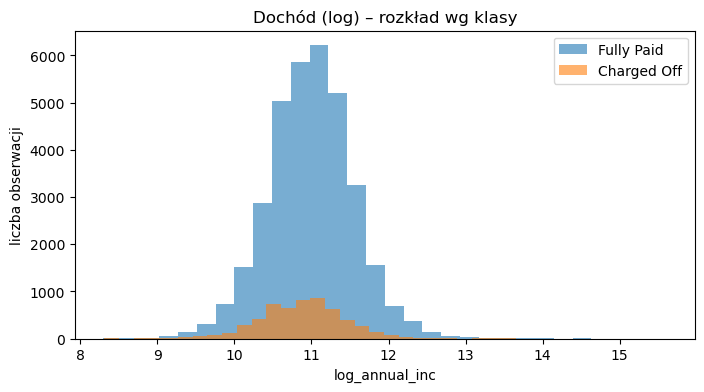

,feature,mean_non_default,mean_default,diff_default_minus_non,t_stat,p_value,n_non_default,n_default
0,Dochód roczny (log),10.989031,10.877883,-0.111149,13.852922,4.037277e-43,34116,5670



ODPOWIEDŹ 4:
Dochód roczny jest istotnie powiązany z ryzykiem niewykonania zobowiązania. W klasie Charged Off średni log-dochód jest niższy niż w Fully Paid (t-test: p=4.037e-43 ***). W praktyce oznacza to, że niższe dochody wiążą się z wyższym ryzykiem defaultu.


In [33]:
plt.figure(figsize=(8,4))
plt.hist(df.loc[df["target_default"]==0, "log_annual_inc"].dropna(), bins=30, alpha=0.6, label="Fully Paid")
plt.hist(df.loc[df["target_default"]==1, "log_annual_inc"].dropna(), bins=30, alpha=0.6, label="Charged Off")
plt.title("Dochód (log) – rozkład wg klasy")
plt.xlabel("log_annual_inc")
plt.ylabel("liczba obserwacji")
plt.legend()
plt.show()

inc_test = ttest_report("log_annual_inc", "Dochód roczny (log)")
display(pd.DataFrame([inc_test]))

print("\nODPOWIEDŹ 4:")
print(
    f"Dochód roczny jest istotnie powiązany z ryzykiem niewykonania zobowiązania. "
    f"W klasie Charged Off średni log-dochód jest "
    f"{'niższy' if inc_test['mean_default'] < inc_test['mean_non_default'] else 'wyższy'} "
    f"niż w Fully Paid (t-test: p={inc_test['p_value']:.3e} {p_to_stars(inc_test['p_value'])}). "
    f"W praktyce oznacza to, że niższe dochody wiążą się z wyższym ryzykiem defaultu."
)

In [34]:
# 2.5 Pytanie 5: Historia zatrudnienia vs default

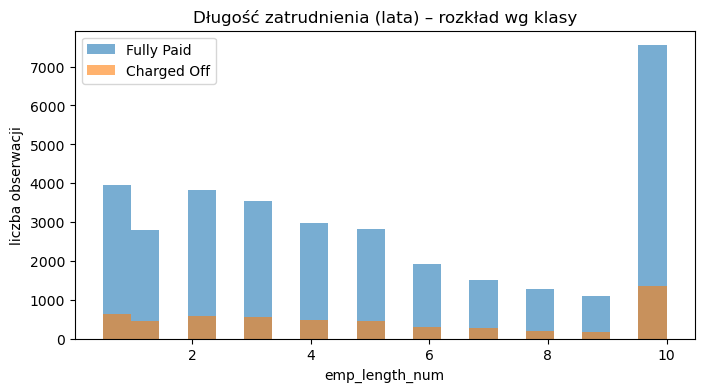

,feature,mean_non_default,mean_default,diff_default_minus_non,t_stat,p_value,n_non_default,n_default
0,Długość zatrudnienia (lata),5.014804,5.148805,0.134001,-2.605506,0.009193,33268,5440



ODPOWIEDŹ 5:
Historia zatrudnienia jest słabiej, ale nadal istotnie powiązana z ryzykiem defaultu. W klasie Charged Off średni staż pracy jest wyższy niż w Fully Paid (t-test: p=9.193e-03 **). Może to sugerować, że stabilność zatrudnienia działa ochronnie, jednak efekt jest mniejszy niż np. dla FICO czy dochodu.


In [35]:
plt.figure(figsize=(8,4))
plt.hist(df.loc[df["target_default"]==0, "emp_length_num"].dropna(), bins=20, alpha=0.6, label="Fully Paid")
plt.hist(df.loc[df["target_default"]==1, "emp_length_num"].dropna(), bins=20, alpha=0.6, label="Charged Off")
plt.title("Długość zatrudnienia (lata) – rozkład wg klasy")
plt.xlabel("emp_length_num")
plt.ylabel("liczba obserwacji")
plt.legend()
plt.show()

emp_test = ttest_report("emp_length_num", "Długość zatrudnienia (lata)")
display(pd.DataFrame([emp_test]))

print("\nODPOWIEDŹ 5:")
print(
    f"Historia zatrudnienia jest słabiej, ale nadal istotnie powiązana z ryzykiem defaultu. "
    f"W klasie Charged Off średni staż pracy jest "
    f"{'niższy' if emp_test['mean_default'] < emp_test['mean_non_default'] else 'wyższy'} "
    f"niż w Fully Paid (t-test: p={emp_test['p_value']:.3e} {p_to_stars(emp_test['p_value'])}). "
    f"Może to sugerować, że stabilność zatrudnienia działa ochronnie, jednak efekt jest mniejszy "
    f"niż np. dla FICO czy dochodu."
)

In [36]:
# 2.6 Wielkość pożyczki vs default

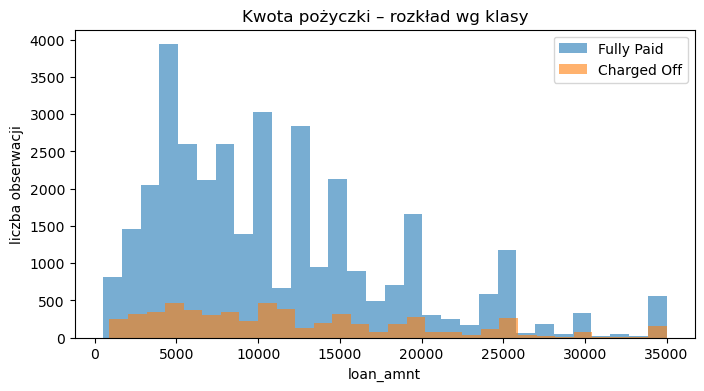

,feature,mean_non_default,mean_default,diff_default_minus_non,t_stat,p_value,n_non_default,n_default
0,Kwota pożyczki,11079.101448,12147.491182,1068.389734,-9.307344,1.701540e-20,34116,5670



ODPOWIEDŹ 6:
Wielkość pożyczki jest istotnie związana z ryzykiem defaultu. W klasie Charged Off średnia kwota pożyczki jest wyższa niż w Fully Paid (t-test: p=1.702e-20 ***). Oznacza to, że większe zobowiązania wiążą się z wyższym ryzykiem niewypłacalności.


In [37]:
plt.figure(figsize=(8,4))
plt.hist(df.loc[df["target_default"]==0, "loan_amnt"].dropna(), bins=30, alpha=0.6, label="Fully Paid")
plt.hist(df.loc[df["target_default"]==1, "loan_amnt"].dropna(), bins=30, alpha=0.6, label="Charged Off")
plt.title("Kwota pożyczki – rozkład wg klasy")
plt.xlabel("loan_amnt")
plt.ylabel("liczba obserwacji")
plt.legend()
plt.show()

loan_test = ttest_report("loan_amnt", "Kwota pożyczki")
display(pd.DataFrame([loan_test]))

print("\nODPOWIEDŹ 6:")
print(
    f"Wielkość pożyczki jest istotnie związana z ryzykiem defaultu. "
    f"W klasie Charged Off średnia kwota pożyczki jest "
    f"{'wyższa' if loan_test['mean_default'] > loan_test['mean_non_default'] else 'niższa'} "
    f"niż w Fully Paid (t-test: p={loan_test['p_value']:.3e} {p_to_stars(loan_test['p_value'])}). "
    f"Oznacza to, że większe zobowiązania wiążą się z wyższym ryzykiem niewypłacalności."
)


In [38]:
#3.	Feature Engineering – utwórz 20 nowych zmiennych (60 pkt)

In [39]:
import numpy as np
import pandas as pd

In [40]:
# 1. Średni FICO (jeśli jeszcze nie istnieje)
if "fico_avg" not in df.columns:
    df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

# 2. Flaga niskiego FICO (dolny kwartyl)
df["low_fico_flag"] = (df["fico_avg"] < df["fico_avg"].quantile(0.25)).astype(int)

# 3. Flaga wysokiego FICO (górny kwartyl)
df["high_fico_flag"] = (df["fico_avg"] > df["fico_avg"].quantile(0.75)).astype(int)

# 4. Bucket FICO (wg standardowych progów)
fico_bins = [0, 580, 670, 740, 800, 1000]
fico_labels = ["poor", "fair", "good", "very_good", "exceptional"]
df["fico_bucket"] = pd.cut(df["fico_avg"], bins=fico_bins, labels=fico_labels, right=False)

# 5. Wiek kredytowy (jeśli jeszcze nie istnieje)
if "credit_age_years" not in df.columns:
    df["credit_age_years"] = (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25

# 6. Flaga krótkiej historii kredytowej
df["short_credit_history_flag"] = (df["credit_age_years"] < df["credit_age_years"].median()).astype(int)

In [41]:
# 7. Logarytm dochodu (stabilizacja rozkładu)
df["log_annual_inc"] = np.log1p(df["annual_inc"])

# 8. Relacja kwoty pożyczki do dochodu
df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)

# 9. Relacja dochodu do kwoty pożyczki
df["income_to_loan"] = df["annual_inc"] / df["loan_amnt"].replace(0, np.nan)

# 10. Relacja raty miesięcznej do dochodu miesięcznego
df["installment_to_income"] = df["installment"] / (df["annual_inc"] / 12).replace(0, np.nan)

# 11. Flaga wysokiego DTI (jeśli kolumna istnieje)
if "dti" in df.columns:
    df["high_dti_flag"] = (df["dti"] > df["dti"].median()).astype(int)
else:
    df["high_dti_flag"] = 0

In [42]:
# 12. Długość kredytu (jeśli jeszcze nie istnieje)
if "term_num" not in df.columns:
    df["term_num"] = df["term"].str.extract(r"(\d+)").astype(float)

# 13. Flaga długiego kredytu (60 miesięcy)
df["long_term_flag"] = (df["term_num"] >= 60).astype(int)

# 14. Flaga wysokiego oprocentowania
df["high_interest_flag"] = (df["int_rate_num"] > df["int_rate_num"].median()).astype(int)

# 15. Kwota pożyczki w logarytmie
df["log_loan_amnt"] = np.log1p(df["loan_amnt"])

In [43]:
# 16. Długość zatrudnienia (jeśli jeszcze nie istnieje)
if "emp_length_num" not in df.columns:
    df["emp_length_num"] = df["emp_length"].str.extract(r"(\d+)").astype(float)

# 17. Flaga długiego zatrudnienia (>= 10 lat)
df["long_employment_flag"] = (df["emp_length_num"] >= 10).astype(int)

# 18. Indeks stabilności zatrudnienia (0–1)
df["employment_stability_index"] = df["emp_length_num"] / df["emp_length_num"].max()

In [44]:
# 19. Flaga posiadania hipoteki
df["has_mortgage_flag"] = (df["home_ownership"].str.upper() == "MORTGAGE").astype(int)

# 20. Flaga najemcy
df["is_renter_flag"] = (df["home_ownership"].str.upper() == "RENT").astype(int)

In [45]:
# 21. Regułowy score ryzyka (ekspercki)
df["risk_score_rule_based"] = (
    2 * df["low_fico_flag"] +
    df["high_interest_flag"] +
    df["long_term_flag"] +
    df["high_dti_flag"] +
    df["is_renter_flag"] +
    df["short_credit_history_flag"]
)

# 22. Indeks presji finansowej
df["financial_pressure_index"] = df["installment_to_income"].clip(upper=2)

# 23. Złożony indeks ryzyka
df["combined_risk_index"] = df["risk_score_rule_based"] + df["financial_pressure_index"]

In [51]:
# 4) KLASTERYZACJA (40 pkt) — 3 metody + dobór liczby klastrów

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [53]:
# Wybór zestawu cech, które opisują klienta/pożyczkę (a nie spłaty)

In [54]:
cluster_features = [
    "fico_avg",
    "credit_age_years",
    "log_annual_inc",
    "loan_amnt",
    "dti",
    "int_rate_num",
    "installment_to_income",
    "loan_to_income",
    "emp_length_num"
]

In [55]:
cluster_features = [c for c in cluster_features if c in df.columns]

print("Użyte cechy do klasteryzacji:", cluster_features)
Xc = df[cluster_features].copy()

Użyte cechy do klasteryzacji: ['fico_avg', 'credit_age_years', 'log_annual_inc', 'loan_amnt', 'dti', 'int_rate_num', 'installment_to_income', 'loan_to_income', 'emp_length_num']


In [56]:
# Wprowadzenie braków + standaryzacja (kluczowe dla klasteryzacji!)
Xc = SimpleImputer(strategy="median").fit_transform(Xc)
Xc = StandardScaler().fit_transform(Xc)

print("Macierz klasteryzacji:", Xc.shape)

Macierz klasteryzacji: (39786, 9)


In [57]:
# Zakres testowanych klastrów - Dobór liczby klastrów dla KMeans: Elbow + Silhouette + Davies–Bouldin

In [58]:
K_RANGE = range(2, 11)

inertias = []
sil_scores = []
db_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xc)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xc, labels))
    db_scores.append(davies_bouldin_score(Xc, labels))

In [59]:
metrics_df = pd.DataFrame({
    "k": list(K_RANGE),
    "inertia": inertias,
    "silhouette": sil_scores,
    "davies_bouldin": db_scores
})

metrics_df

,k,inertia,silhouette,davies_bouldin
0,2,289018.147387,0.193066,1.914313
1,3,251189.442534,0.161607,1.820805
2,4,227905.422361,0.161151,1.753916
3,5,212535.804610,0.141983,1.801650
4,6,201473.194430,0.133634,1.833772
5,7,192715.617055,0.126877,1.795673
6,8,184770.646396,0.127662,1.802672
7,9,177449.488281,0.127998,1.738008
8,10,171522.189860,0.127471,1.707730


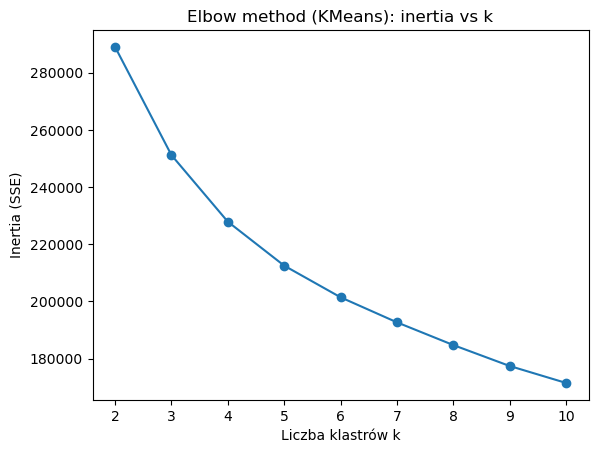

In [60]:
# WYKRES 1: Elbow (inertia)
plt.figure()
plt.plot(metrics_df["k"], metrics_df["inertia"], marker="o")
plt.title("Elbow method (KMeans): inertia vs k")
plt.xlabel("Liczba klastrów k")
plt.ylabel("Inertia (SSE)")
plt.show()

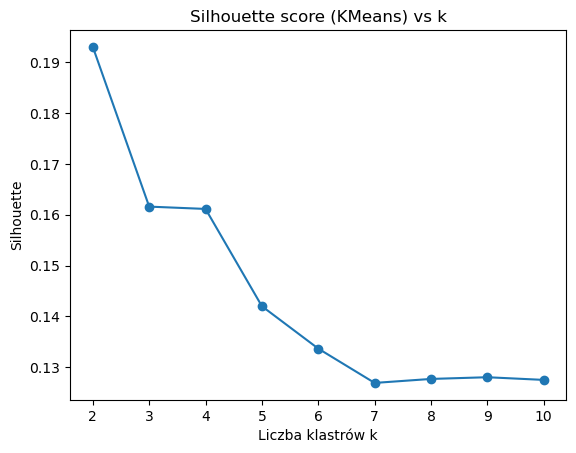

In [62]:
# WYKRES 2: Silhouette
plt.figure()
plt.plot(metrics_df["k"], metrics_df["silhouette"], marker="o")
plt.title("Silhouette score (KMeans) vs k")
plt.xlabel("Liczba klastrów k")
plt.ylabel("Silhouette")
plt.show()

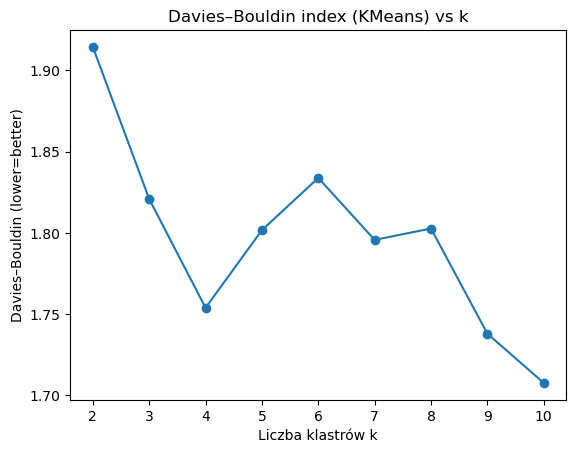

In [63]:
# WYKRES 3: Davies–Bouldin (im niżej tym lepiej)
plt.figure()
plt.plot(metrics_df["k"], metrics_df["davies_bouldin"], marker="o")
plt.title("Davies–Bouldin index (KMeans) vs k")
plt.xlabel("Liczba klastrów k")
plt.ylabel("Davies–Bouldin (lower=better)")
plt.show()

In [64]:
# Prosty wybór k: bierzemy k z najwyższym silhouette
best_k = int(metrics_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Wybrane k (najwyższe silhouette):", best_k)

Wybrane k (najwyższe silhouette): 2


In [65]:
# Metoda 1: KMeans (z wybranym k)

In [66]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster_kmeans"] = kmeans.fit_predict(Xc)

df["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    25096
1    14690
Name: count, dtype: int64

In [67]:
#Metoda 2: Klasteryzacja hierarchiczna (Agglomerative)

In [68]:
agg = AgglomerativeClustering(n_clusters=best_k)
df["cluster_agg"] = agg.fit_predict(Xc)

df["cluster_agg"].value_counts().sort_index()

cluster_agg
0    27575
1    12211
Name: count, dtype: int64

In [69]:
#Metoda 3: DBSCAN (gęstościowa) — dobór parametrów krok po kroku

In [70]:
eps_values = [0.6, 0.8, 1.0, 1.2]
min_samples = 20

dbscan_results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(Xc)

    n_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_rate = np.mean(labels == -1)

    # silhouette tylko jeśli jest >=2 klastry
    sil = None
    dbi = None
    if n_clusters >= 2:
        sil = silhouette_score(Xc, labels)
        dbi = davies_bouldin_score(Xc, labels)

    dbscan_results.append((eps, min_samples, n_clusters, noise_rate, sil, dbi))

dbscan_df = pd.DataFrame(dbscan_results, columns=["eps","min_samples","n_clusters","noise_rate","silhouette","davies_bouldin"])
dbscan_df

,eps,min_samples,n_clusters,noise_rate,silhouette,davies_bouldin
0,0.6,20,3,0.998341,-0.278931,1.753335
1,0.8,20,4,0.622656,-0.145795,2.118715
2,1.0,20,1,0.247876,NaN,NaN
3,1.2,20,1,0.089051,NaN,NaN


In [71]:
dbscan_df_valid = dbscan_df.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False)
dbscan_df_valid

,eps,min_samples,n_clusters,noise_rate,silhouette,davies_bouldin
1,0.8,20,4,0.622656,-0.145795,2.118715
0,0.6,20,3,0.998341,-0.278931,1.753335


In [72]:
best_eps = float(dbscan_df_valid.iloc[0]["eps"])
print("Wybrane eps:", best_eps)

db = DBSCAN(eps=best_eps, min_samples=min_samples)
df["cluster_dbscan"] = db.fit_predict(Xc)

df["cluster_dbscan"].value_counts().sort_index()

Wybrane eps: 0.8


cluster_dbscan
-1    24773
 0    14961
 1       16
 2       13
 3       23
Name: count, dtype: int64

In [73]:
#Ocena segmentów: liczność + default_rate + średnie cech (tabele do raportu)

In [79]:
def segment_report(df, cluster_col, features, drop_noise=True):
    """
    df           - dataframe z danymi i kolumnami cluster_* oraz target_default
    cluster_col  - nazwa kolumny z etykietą klastra (np. 'cluster_kmeans')
    features     - lista cech, które chcesz uśrednić w segmentach
    drop_noise   - jeśli True, usuwa cluster = -1 (noise) w DBSCAN
    """


    rep = (
        df.groupby(cluster_col)
          .agg(
              count=("target_default", "size"),
              default_rate=("target_default", "mean")
          )
    )

    means = (
        df.groupby(cluster_col)[features]
          .mean(numeric_only=True)
    )

   
    out = rep.join(means, how="left")

   
    if drop_noise and (-1 in out.index):
        out = out.drop(index=-1)

    out = out.sort_values("default_rate", ascending=False)

    return out


In [80]:
try:
    cluster_features
except NameError:
    cluster_features = ["fico_avg","credit_age_years","log_annual_inc","loan_amnt","dti","int_rate_num","installment_to_income","loan_to_income","emp_length_num"]


cluster_features = [c for c in cluster_features if c in df.columns]

print("Cechy do profilu segmentów:", cluster_features)


Cechy do profilu segmentów: ['fico_avg', 'credit_age_years', 'log_annual_inc', 'loan_amnt', 'dti', 'int_rate_num', 'installment_to_income', 'loan_to_income', 'emp_length_num']


In [81]:
kmeans_seg_table = segment_report(df, "cluster_kmeans", cluster_features, drop_noise=False)
agg_seg_table    = segment_report(df, "cluster_agg", cluster_features, drop_noise=False)
dbscan_seg_table = segment_report(df, "cluster_dbscan", cluster_features, drop_noise=True)

print("\n=== KMEANS: segmenty (liczność + default_rate + średnie cech) ===")
display(kmeans_seg_table)

print("\n=== AGGLOMERATIVE: segmenty (liczność + default_rate + średnie cech) ===")
display(agg_seg_table)

print("\n=== DBSCAN: segmenty (liczność + default_rate + średnie cech; bez noise=-1) ===")
display(dbscan_seg_table)


=== KMEANS: segmenty (liczność + default_rate + średnie cech) ===


,count,default_rate,fico_avg,credit_age_years,log_annual_inc,loan_amnt,dti,int_rate_num,installment_to_income,loan_to_income,emp_length_num
cluster_kmeans,,,,,,,,,,,
1,14690,0.189449,713.616406,13.910853,10.880660,17234.685160,15.109029,0.136935,0.105182,0.306641,5.244637
0,25096,0.115038,718.977407,13.724879,11.027354,7717.300566,12.269290,0.110529,0.042775,0.118636,4.910510



=== AGGLOMERATIVE: segmenty (liczność + default_rate + średnie cech) ===


,count,default_rate,fico_avg,credit_age_years,log_annual_inc,loan_amnt,dti,int_rate_num,installment_to_income,loan_to_income,emp_length_num
cluster_agg,,,,,,,,,,,
1,12211,0.179101,721.186389,15.712169,11.084374,18929.172467,15.303679,0.132869,0.098285,0.293852,6.049719
0,27575,0.126310,715.143246,12.943924,10.923956,7822.548504,12.438387,0.114703,0.051439,0.141201,4.581669



=== DBSCAN: segmenty (liczność + default_rate + średnie cech; bez noise=-1) ===


,count,default_rate,fico_avg,credit_age_years,log_annual_inc,loan_amnt,dti,int_rate_num,installment_to_income,loan_to_income,emp_length_num
cluster_dbscan,,,,,,,,,,,
3,23,0.173913,689.826087,8.934321,10.481670,12717.391304,22.676522,0.133504,0.144558,0.355755,1.565217
2,13,0.153846,694.307692,11.839309,10.957863,16496.153846,22.052308,0.136592,0.117057,0.286746,9.692308
0,14961,0.118575,706.819531,10.913653,10.921120,7496.918655,13.787726,0.114377,0.051146,0.134954,4.471594
1,16,0.000000,783.875000,17.924880,11.718002,9425.000000,2.628125,0.063256,0.027610,0.076930,9.875000


In [82]:
#4.2 5 MODELI + PORÓWNANIE AUROC (50 pkt)

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [84]:

y = df["target_default"]


drop_cols = [
    "target_default",
    "loan_status",
    "cluster_kmeans",
    "cluster_agg",
    "cluster_dbscan"
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")


num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Liczba cech numerycznych:", len(num_cols))
print("Liczba cech kategorycznych:", len(cat_cols))

Liczba cech numerycznych: 144
Liczba cech kategorycznych: 31


In [85]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (31828, 175)
Test: (7958, 175)


In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score

In [94]:
#Trenowanie modeli + obliczenie AUROC